## Task


The aim of the assignment is to apply the NLP techniques you have learnt in class to analyse one of the 
datasets described below.   
• Note: some of the datasets are quite large, so you may need to sample a small percentage of the 
data and work that. 
The exact tasks performed may depend on the dataset chosen, but we would expect to see some of the 
following: 
#### 1. Preliminary analysis:  
Briefly describe the data:

What is the structure of the dataset? What type of task was the dataset collected for? 

What type of documents does it contain? How many are there? How long are they on average and 

what is their distribution? 

How big is the vocabulary of the collection? How big is the vocabulary of a document on average? 

Play around with documents using code from the early parts of the course. For example, you could:
Cluster the documents, visualise the clusters and to try to understand what types of groups are 
present.

Index the documents so that you can perform keyword search over them. 

Train a Word2Vec embedding and investigate the properties of the resulting embedding. 
#### 2. Training models: 
Each dataset has been created with a particular task in mind. You don’t necessarily need to tackle that 
particular problem, but you do need to train some model(s) on the data:

train ML models (e.g. a linear classifier, an LSTM and/or a Transformer) to perform a particular 

task on the data; 
if possible, try to fine-tune a pretrained models on the same task and compare their performance; 

try an LLM on the task, comparing one, few and zero-shot performance;  
and perhaps even try to fine-tune a small LLM on the task (if it makes sense to do so).   
#### 3. Possible extensions: 
Depending on the dataset chosen there will be many additional investigations that you could perform, 
for example:  
- investigate another task on the same dataset  
- investigate the same task on a related dataset 
- use text-to-speech and speech-to-text models to create a voice interactive chatbot
- create your own dialog dataset by transcribing audio conversations (e.g. using MS Teams).  

In [68]:
from datasets import load_dataset

dataset = load_dataset("neural-bridge/rag-dataset-12000")

In [69]:
dataset

DatasetDict({
    train: Dataset({
        features: ['context', 'question', 'answer'],
        num_rows: 9600
    })
    test: Dataset({
        features: ['context', 'question', 'answer'],
        num_rows: 2400
    })
})

In [70]:
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

In [71]:
print('Train dataset len:', len(train_df))
print('Test dataset len:', len(test_df))

Train dataset len: 9600
Test dataset len: 2400


In [72]:
### showing some examples

context = train_df['context'][4]
question = train_df['question'][4]
answer = train_df['answer'][4]

In [73]:
context

'Gunnar Nelson took his time on the feet against Zak Cummings tonight in the co-main event of UFC Fight Night 46, but when he finally saw an opportunity to switch up the gears in the second round he pounced on it, taking his opponent to the mat, seizing his back and locking in the fight-ending choke almost effortlessly.\nRound One:\nNelson in his usual Karate style stance keeps out of range of Cummings early strikes. Then he presses into the clinch, but Cummings matches him and they jockey for position. As they break apart Nelson lands a good knee.\nNelson lands a right hook. he misses with an overhand. Nelson very relaxed, but he’s very alert and continually makes Cumming miss by backing up just enough. A right hand counter lands for Nelson, but then Cummings moves to his back and clinches up. Nelson turns though and then breaks away from the clinch.\nA head kick is blocked by Cummings. Pace slowed a little now in the final 90 seconds. Cummings leaps in and nelson counters with a punc

In [74]:
question

'How did Gunnar Nelson win the fight against Zak Cummings at UFC Fight Night 46?'

In [75]:
answer

'Gunnar Nelson won the fight against Zak Cummings at UFC Fight Night 46 by taking his opponent to the mat, seizing his back and locking in a rear-naked choke, forcing Cummings to tap with only twelve seconds of the second round remaining.'

### Data Exploration

In [76]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from nltk.stem import PorterStemmer

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from textblob import TextBlob
from tqdm import tqdm

In [77]:
# Count NaN / null values per column
train_null_counts = train_df.isna().sum()

# Count NaN / null values per column
test_null_counts = test_df.isna().sum()

null_counts = train_null_counts + test_null_counts
# Print the result
print(f"NaN/null values per column: {null_counts}")
print(f"NaN/null values per column in train: {train_null_counts}")
print(f"NaN/null values per column in test: {test_null_counts}")


train_df = train_df.dropna()
test_df = test_df.dropna()

print('Any missing values: ')
print(train_df.isnull().any() & test_df.isnull().any())

NaN/null values per column: context     0
question    3
answer      3
dtype: int64
NaN/null values per column in train: context     0
question    2
answer      2
dtype: int64
NaN/null values per column in test: context     0
question    1
answer      1
dtype: int64
Any missing values: 
context     False
question    False
answer      False
dtype: bool


In [78]:
# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')


# Initialize stopwords
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Analyze document lengths
context_lengths = []
question_lengths = []
vocab = set()

all_tokens = []

train_df_tokenized = []

# Function to preprocess text
def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalnum()]  # Remove punctuation
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    #tokens = [stemmer.stem(word) for word in tokens]  # Apply stemming
    return tokens

def append_tokens(entry):
    context_tokens = preprocess(entry['context'])
    question_tokens = preprocess(entry['question'])
    answer_tokens = preprocess(entry['answer'])
    
    context_lengths.append(len(context_tokens))
    question_lengths.append(len(question_tokens))
    vocab.update(context_tokens)
    vocab.update(question_tokens)

    all_tokens.extend(context_tokens)
    all_tokens.extend(question_tokens)

    train_df_tokenized.append({'context': context_tokens, 'question': question_tokens, 'answer': answer_tokens})


train_df.apply(lambda entry: append_tokens(entry), axis=1)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0       None
1       None
2       None
3       None
4       None
        ... 
9595    None
9596    None
9597    None
9598    None
9599    None
Length: 9598, dtype: object

In [79]:
train_df_tokenized = pd.DataFrame(train_df_tokenized, columns=['context', 'question', 'answer'])
train_df_tokenized.head()

,context,question,answer
0,"[caption, tasmanian, berry, grower, nic, hanse...","[berry, export, summary, 2028, purpose]","[berry, export, summary, 2028, dedicated, expo..."
1,"[rwsn, collaborations, southern, africa, study...","[benefits, reported, access, water, sources]","[benefits, reported, access, water, sources, i..."
2,"[android, applications, categories, descriptio...","[unique, features, coolands, twitter, app]","[unique, features, coolands, twitter, app, inc..."
3,"[unequal, india, question, simple, answer, 60,...","[main, difference, national, sample, survey, n...","[main, difference, nss, ihds, terms, measuring..."
4,"[gunnar, nelson, took, time, feet, zak, cummin...","[gunnar, nelson, win, fight, zak, cummings, uf...","[gunnar, nelson, fight, zak, cummings, ufc, fi..."


In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join tokens back into strings for each field
train_df_tokenized['context_str'] = train_df_tokenized['context'].apply(lambda tokens: ' '.join(tokens))
train_df_tokenized['question_str'] = train_df_tokenized['question'].apply(lambda tokens: ' '.join(tokens))

# Option 1: TF-IDF on context only
vectorizer_context = TfidfVectorizer()
tfidf_context = vectorizer_context.fit_transform(train_df_tokenized['context_str'])

# Option 2: TF-IDF on question only
vectorizer_question = TfidfVectorizer()
tfidf_question = vectorizer_question.fit_transform(train_df_tokenized['question_str'])

# Option 3: TF-IDF on combined context + question
train_df_tokenized['combined'] = train_df_tokenized['context_str'] + ' ' + train_df_tokenized['question_str']
vectorizer_combined = TfidfVectorizer()
tfidf_combined = vectorizer_combined.fit_transform(train_df_tokenized['combined'])

In [81]:
tfidf_context_df = pd.DataFrame(tfidf_context.toarray(), columns=vectorizer_context.get_feature_names_out())
tfidf_context_df

,00,000,0000,00000,000000,00000000000000000,000000311428,00003376,0001,0002,...,𝐀𝐫𝐞,𝐁𝐢𝐥𝐥𝐢𝐧𝐠,𝐂𝐨𝐦𝐩𝐚𝐧𝐲,𝐋𝐨𝐨𝐤𝐢𝐧𝐠,𝐌𝐞𝐝𝐢𝐜𝐚𝐥,𝐟𝐨𝐫,𝐨𝐮𝐭,𝐲𝐨𝐮,𝚜𝚔𝚎𝚝𝚌𝚑𝚢,𝚝𝚛𝚊𝚜𝚑
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9595,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [82]:
tfidf_question_df = pd.DataFrame(tfidf_question.toarray(), columns=vectorizer_question.get_feature_names_out())
tfidf_question_df

,00210,00215235,0047,007119908x,0099yanaemon,02474,03038,03801,04,04530,...,zorha,zorn,zotero,zuckerberg,zuma,zurich,zuza,émile,øvstedal,čile
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9595,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [83]:
tfidf_combined_df = pd.DataFrame(tfidf_combined.toarray(), columns=vectorizer_combined.get_feature_names_out())
tfidf_combined_df

,00,000,0000,00000,000000,00000000000000000,000000311428,00003376,0001,0002,...,𝐀𝐫𝐞,𝐁𝐢𝐥𝐥𝐢𝐧𝐠,𝐂𝐨𝐦𝐩𝐚𝐧𝐲,𝐋𝐨𝐨𝐤𝐢𝐧𝐠,𝐌𝐞𝐝𝐢𝐜𝐚𝐥,𝐟𝐨𝐫,𝐨𝐮𝐭,𝐲𝐨𝐮,𝚜𝚔𝚎𝚝𝚌𝚑𝚢,𝚝𝚛𝚊𝚜𝚑
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9595,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


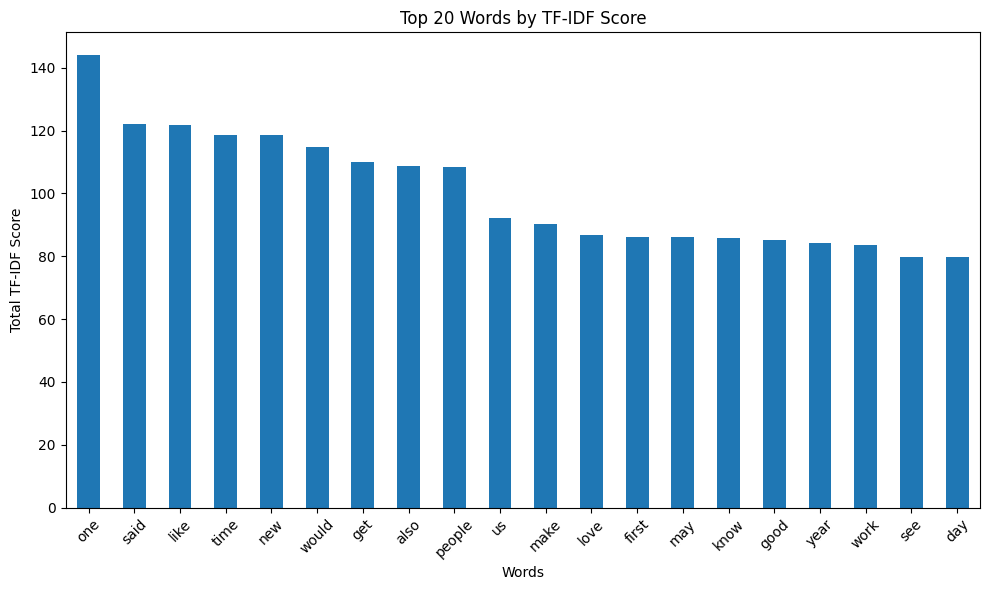

In [84]:
word_scores = tfidf_context_df.sum(axis=0).sort_values(ascending=False)

# Plot top 20 words
top_n = 20
top_words = word_scores.head(top_n)

plt.figure(figsize=(10, 6))
top_words.plot(kind='bar')
plt.title(f"Top {top_n} Words by TF-IDF Score")
plt.xlabel("Words")
plt.ylabel("Total TF-IDF Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
feature_names = vectorizer_context.get_feature_names_out()

# Function to get top N words for a single document
def get_top_n_words(row, n):
    row_data = row.toarray().flatten()
    top_indices = row_data.argsort()[::-1][:n]
    
    return [(feature_names[i], row_data[i]) for i in top_indices if row_data[i] > 0]

N = 5
train_df_tokenized[f'top_{N}_tfidf_words_context'] = [
    get_top_n_words(tfidf_context[i], N) for i in range(tfidf_context.shape[0])
]

In [86]:
train_df_tokenized.head()

,context,question,answer,context_str,question_str,combined,top_5_tfidf_words_context
0,"[caption, tasmanian, berry, grower, nic, hanse...","[berry, export, summary, 2028, purpose]","[berry, export, summary, 2028, dedicated, expo...",caption tasmanian berry grower nic hansen show...,berry export summary 2028 purpose,caption tasmanian berry grower nic hansen show...,"[(export, 0.3148326155741806), (hort, 0.240575..."
1,"[rwsn, collaborations, southern, africa, study...","[benefits, reported, access, water, sources]","[benefits, reported, access, water, sources, i...",rwsn collaborations southern africa study revi...,benefits reported access water sources,rwsn collaborations southern africa study revi...,"[(supported, 0.361379184613742), (water, 0.325..."
2,"[android, applications, categories, descriptio...","[unique, features, coolands, twitter, app]","[unique, features, coolands, twitter, app, inc...",android applications categories description co...,unique features coolands twitter app,android applications categories description co...,"[(tweets, 0.47424744609680974), (tweet, 0.2828..."
3,"[unequal, india, question, simple, answer, 60,...","[main, difference, national, sample, survey, n...","[main, difference, nss, ihds, terms, measuring...",unequal india question simple answer 60 years ...,main difference national sample survey nss ind...,unequal india question simple answer 60 years ...,"[(nss, 0.5520503960121861), (inequality, 0.313..."
4,"[gunnar, nelson, took, time, feet, zak, cummin...","[gunnar, nelson, win, fight, zak, cummings, uf...","[gunnar, nelson, fight, zak, cummings, ufc, fi...",gunnar nelson took time feet zak cummings toni...,gunnar nelson win fight zak cummings ufc fight...,gunnar nelson took time feet zak cummings toni...,"[(nelson, 0.5746039405431613), (cummings, 0.57..."


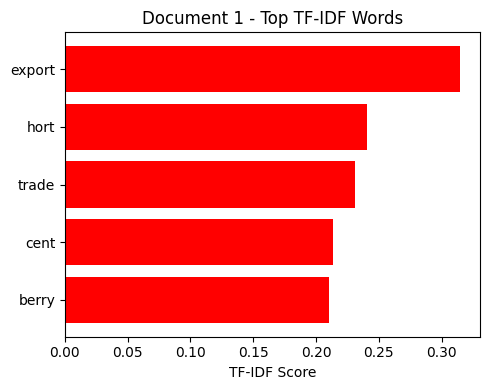

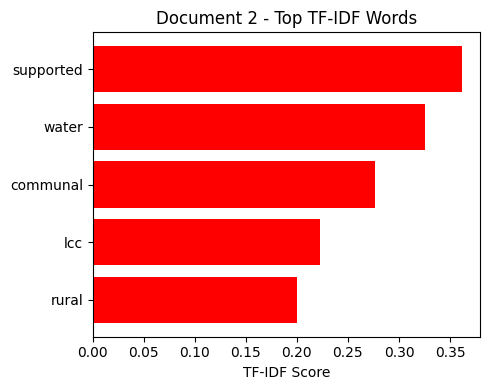

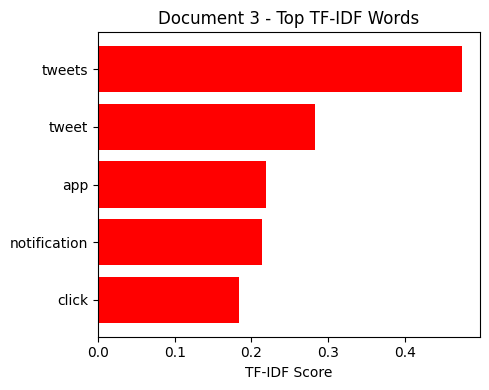

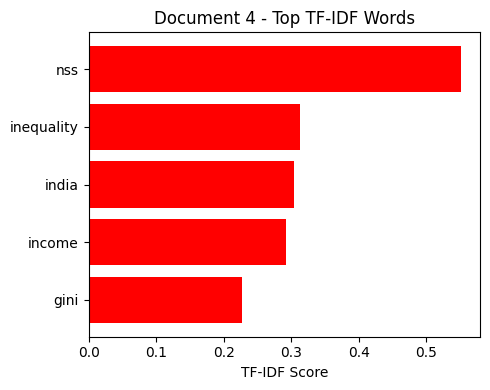

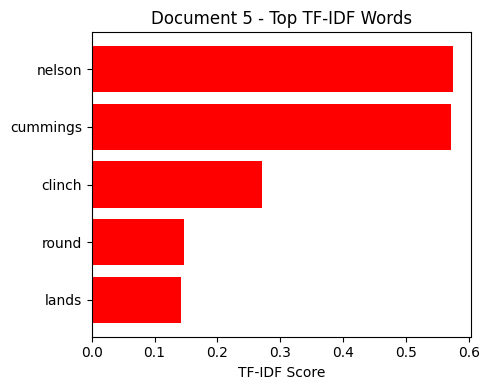

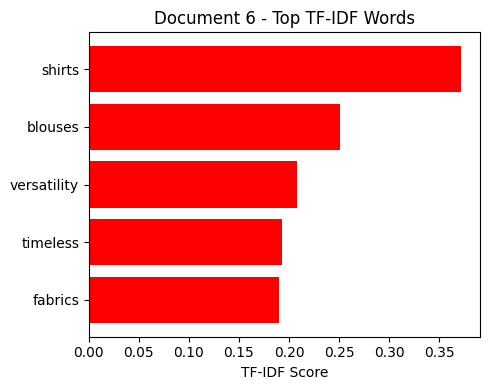

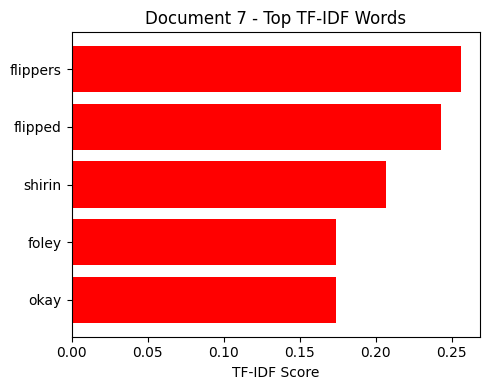

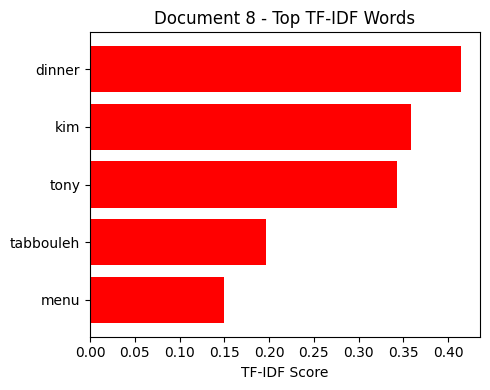

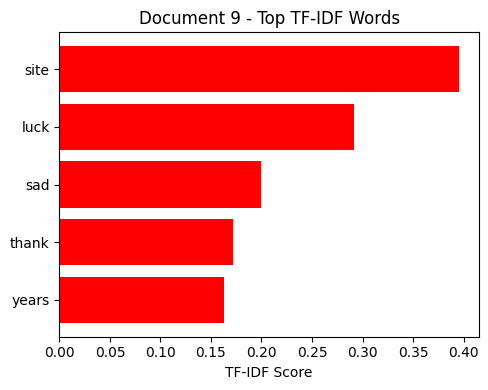

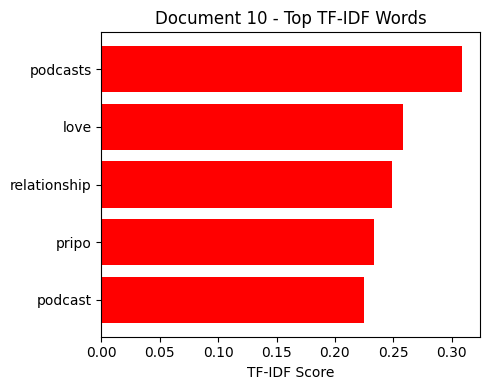

In [87]:
def plot_top_words_with_scores(word_score_pairs, title='Top TF-IDF Words'):
    words, scores = zip(*word_score_pairs)
    plt.figure(figsize=(5, 4))
    plt.barh(words[::-1], scores[::-1], color='red')  # reverse for descending order
    plt.xlabel('TF-IDF Score')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Example: visualize document 0
for i in range(10):
    plot_top_words_with_scores(train_df_tokenized.loc[i, f'top_{N}_tfidf_words_context'],
                           title=f'Document {i+1} - Top TF-IDF Words')


In [88]:
fdist = FreqDist(all_tokens)
fdist

FreqDist({'one': 14432, 'also': 10326, 'new': 10136, 'time': 10131, 'like': 9989, 'would': 8828, 'get': 8782, 'said': 7855, 'people': 7767, 'first': 6947, ...})

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(fdist)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Vocabulary")
plt.show()

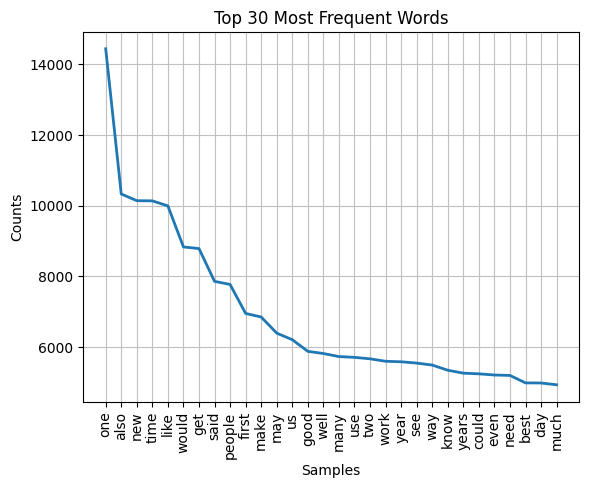

In [90]:
fdist.plot(30,  title="Top 30 Most Frequent Words")

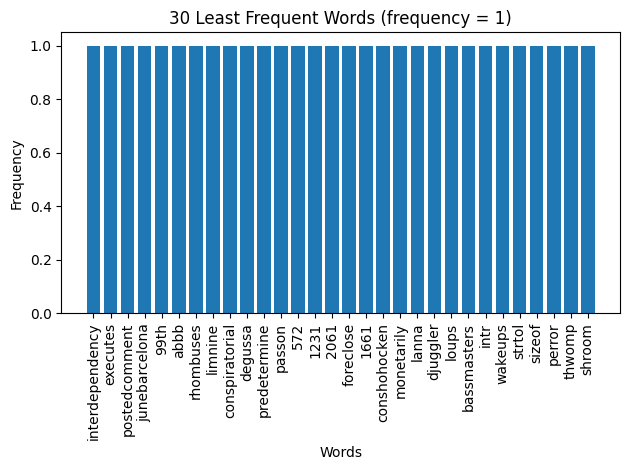

In [91]:
import pandas as pd
import seaborn as sns

least_freq = fdist.most_common()[-30:]
least_freq = pd.DataFrame(least_freq, columns=['word', 'count'])
plt.bar(least_freq['word'], least_freq['count'])
plt.xticks(rotation=90)
plt.title("30 Least Frequent Words (frequency = 1)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Number of documents: 9598
Average context length: 321.12 tokens
Average question length: 6.81 tokens
Vocabulary size: 128313


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



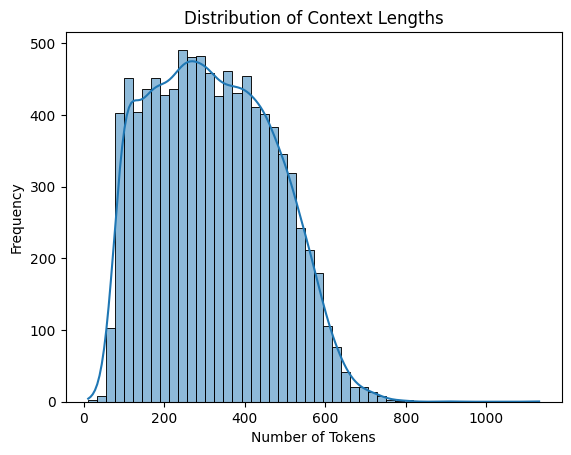

In [92]:
# Print statistics
print(f"Number of documents: {len(train_df)}")
print(f"Average context length: {sum(context_lengths)/len(context_lengths):.2f} tokens")
print(f"Average question length: {sum(question_lengths)/len(question_lengths):.2f} tokens")
print(f"Vocabulary size: {len(vocab)}")

# Plot distribution of context lengths
sns.histplot(context_lengths, bins=50, kde=True)
plt.title('Distribution of Context Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



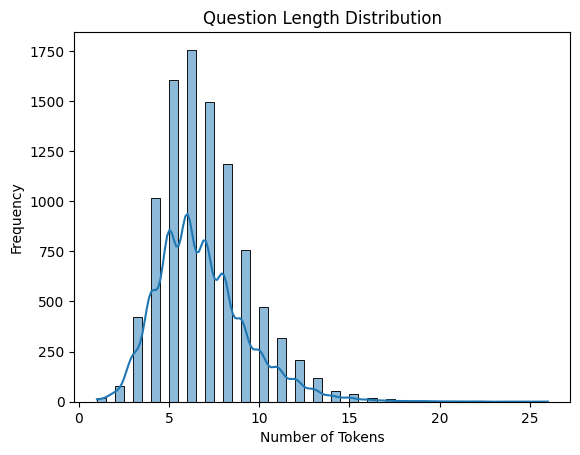

In [93]:
sns.histplot(question_lengths, bins=50, kde=True)
plt.title("Question Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

### Create embeddings with Word2Vec 



In [94]:
train_df_tokenized['context'][:10]

0    [caption, tasmanian, berry, grower, nic, hanse...
1    [rwsn, collaborations, southern, africa, study...
2    [android, applications, categories, descriptio...
3    [unequal, india, question, simple, answer, 60,...
4    [gunnar, nelson, took, time, feet, zak, cummin...
5    [prices, indicated, catalogue, include, shippi...
6    [dan, foley, survivor, portrayal, unfair, late...
7    [week, menu, two, table, menu, week, may, 15, ...
8    [commenting, almostcool, spam, pretty, gloriou...
9    [5, great, podcasts, love, much, like, think, ...
Name: context, dtype: object

In [95]:
import re

def tokenize(text):
    # Remove non-word characters, lowercase, split into tokens
    return re.sub(r'\W+', ' ', str(text)).lower().split()
    

tokenized_contexts = train_df_tokenized['context'].apply(tokenize)
tokenized_questions = train_df_tokenized['question'].apply(tokenize)
tokenized_answers = train_df_tokenized['answer'].apply(tokenize)

# Optionally filter out short sentences (more than 3 tokens)
tokenized_contexts = tokenized_contexts[tokenized_contexts.apply(lambda x: len(x) > 3)]
tokenized_questions = tokenized_questions[tokenized_questions.apply(lambda x: len(x) > 3)]
tokenized_answers = tokenized_answers[tokenized_answers.apply(lambda x: len(x) > 3)]

In [ ]:
all_tokenized_sentences = tokenized_contexts.tolist() + tokenized_questions.tolist() + tokenized_answers.tolist()

In [ ]:
from gensim.models.word2vec import Word2Vec

d = 30

model = Word2Vec(all_tokenized_sentences, vector_size=d, min_count=5, window=10) # default model is skipgram (it tends to perform better)

In [ ]:
len(model.wv)
#print(model.wv.key_to_index)

38654

In [ ]:
term = 'house'
model.wv[term]
model.wv.most_similar(term)

[('apartment', 0.7683624029159546),
 ('home', 0.6892566680908203),
 ('neighborhood', 0.6866540908813477),
 ('cottage', 0.6674872040748596),
 ('terraced', 0.6571559309959412),
 ('bedroom', 0.657113254070282),
 ('doors', 0.6502594351768494),
 ('basement', 0.6461154818534851),
 ('parcel', 0.6439531445503235),
 ('residence', 0.6415333151817322)]

In [ ]:
import random

sample = random.sample(list(model.wv.key_to_index), 1000)
word_vectors = model.wv[sample]
word_vectors

array([[ 1.45857036e-01, -5.93880951e-01,  9.73428905e-01, ...,
         4.83961940e-01,  7.07251370e-01, -2.51040369e-01],
       [-1.11481383e-01,  1.83490254e-02,  9.33479071e-02, ...,
         1.40609294e-02,  1.97330322e-02, -1.12514332e-01],
       [-3.27931315e-01, -3.02412838e-01, -1.79916561e-01, ...,
         4.03226942e-01, -1.97407231e-01, -2.39429042e-01],
       ...,
       [ 7.14376867e-02, -1.22931093e-01,  1.11478947e-01, ...,
        -1.66243184e-02,  1.01238154e-01, -9.65742618e-02],
       [-1.20102093e-02, -1.88902140e-01,  1.63869902e-01, ...,
         2.35849526e-02, -1.57234957e-04, -2.92037398e-01],
       [ 8.57393742e-02, -3.01412165e-01,  2.48232380e-01, ...,
        -1.23059116e-01,  4.57815379e-02, -7.09519908e-02]], dtype=float32)

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, n_iter=2000)
tsne_embedding = tsne.fit_transform(word_vectors)

In [ ]:
import numpy as np

x, y, z = np.transpose(tsne_embedding)

In [ ]:
import plotly.express as px

fig = px.scatter_3d(x=x, y=y, z=z)
fig.update_traces(marker=dict(size=3,line=dict(width=2)))
fig.show()

In [ ]:
fig = px.scatter_3d(x=x[:200],y=y[:200],z=z[:200],text=sample[:200])
fig.update_traces(marker=dict(size=3,line=dict(width=2)),textfont_size=10)
fig.show()

In [ ]:
colours = ['red','green','blue','orange','yellow','purple','pink','cream','brown','black','white','gray']

word_vectors = model.wv[colours+sample]

tsne = TSNE(n_components=3)
tsne_embedding = tsne.fit_transform(word_vectors)

x, y, z = np.transpose(tsne_embedding)

In [ ]:
r = (-200,200)
fig = px.scatter_3d(x=x, y=y, z=z, range_x=r, range_y=r, range_z=r, text=colours + [None] * 1000)
fig.update_traces(marker=dict(size=3,line=dict(width=2)),textfont_size=10)
fig.show()

### Clustering

Now that we have the embeddings of the words, we would like to make operations fast with them. \
Faiss is a library for efficient similarity search and clustering of dense vectors. It contains algorithms that search in sets of vectors of any size, up to ones that possibly do not fit in RAM. It also contains supporting code for evaluation and parameter tuning. \
Faiss is written in C++ with complete wrappers for Python/numpy. Some of the most useful algorithms are implemented on the GPU. It is developed primarily at Meta's Fundamental AI Research group. \
Let's install it and try to make a search!

In [ ]:
!pip install faiss-cpu

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
import faiss
index = faiss.IndexFlatL2(d) 

In [ ]:
# This creates a matrix with the embeddings of the words as rows
words = list(model.wv.key_to_index.keys())
word_vectors = np.array([model.wv[word] for word in words]).astype("float32") 

# This creates an index 
index = faiss.IndexFlatL2(word_vectors.shape[1])
index.add(word_vectors)

In [ ]:
# Let's perform a search
query_word = 'house'
query_vector = np.array([model.wv[query_word]]).astype("float32")
D, I = index.search(query_vector, k=10)  # D = distances, I = indices
similar_words = [(words[i],d) for i, d in zip(I[0], D[0])]
print(f"Words similar to '{query_word}':", similar_words)

Words similar to 'house': [('house', 0.0), ('apartment', 66.8896), ('neighborhood', 91.82518), ('doors', 93.909615), ('home', 97.5309), ('owner', 97.672295), ('residence', 100.55711), ('homes', 102.14918), ('farm', 102.744446), ('basement', 103.88821)]


In [ ]:
D.shape

(1, 10)

In [ ]:
I.shape

(1, 10)

Let's create a function that shows example fo clusters

In [ ]:
def show_cluster_examples(column, n_clusters=5, top_n=30):
    if column == "question": 
        df = pd.DataFrame({column: tokenized_questions, 'cluster': labels})   
    elif column == "context": 
        df = pd.DataFrame({column: tokenized_context, 'cluster': labels})
    elif column == "answer": 
        df = pd.DataFrame({column: tokenized_answers, 'cluster': labels})
    
    unique_clusters = sorted(df['cluster'].unique()) # Get unique labels and sort them
    clusters_to_show = unique_clusters[:n_clusters]

    for i in clusters_to_show:
        print(f"\n🔹 Cluster {i} (size={len(df[df.cluster==i])}):")
        examples = df[df.cluster == i][column].sample(min(top_n, len(df[df.cluster == i])), random_state=0)
        for q in examples:
            print("  -", q)

### Let's now use the embeddings of the words provided by Word2Vec

The Word2Vec gives us the embeddings of words, now we have to compute the embeddings of sentences to then compare them and cluster them 

In [ ]:
def sentence_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

question_embeddings = np.array([sentence_embedding(tokens, model) for tokens in tokenized_questions])
context_embeddings = np.array([sentence_embedding(tokens, model) for tokens in tokenized_contexts])
answer_embeddings = np.array([sentence_embedding(tokens, model) for tokens in tokenized_answers])

This is a function to guess the magnitude of k. It works in this way, we calculate the cosine similarity of the sentences embeddings and count them 

In [ ]:
from sklearn.cluster import KMeans

# Compute cosine similarity matrix with FAISS
def cosine_similarity_faiss(vectors):
    vectors = np.asarray(vectors).astype('float32')
    normalized = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    similarity_matrix = np.matmul(normalized, normalized.T) 
    return similarity_matrix


# Extract similar pairs based on a threshold
def extract_similar_pairs(sim_matrix, threshold):
    n = sim_matrix.shape[0]
    similar_pairs = []

    for i in range(1, n):
        for j in range(i):
            if sim_matrix[i, j] > threshold:
                similar_pairs.append((i, j, sim_matrix[i, j]))
    return similar_pairs


def sim_matrix_density(embeddings, threshold=0.8):
    S = cosine_similarity_faiss(embeddings)
    print(S.shape)
    return len(extract_similar_pairs(S, threshold))/(S.shape[0] * S.shape[1])*100, S

In [ ]:
# L'idea dietro a questa funzione è sostanzialmente di capire che k usare nel KNN
# Contando le frasi che sono simili tra di loro 
# Si capisce euristicamente se si abbia bisogno di più o meno cluster

perc, S = sim_matrix_density(question_embeddings, 0.7) 


####
# 5 mins -> 1182 clusters

(9074, 9074)


In [ ]:
print(perc)

0.6909417529388441


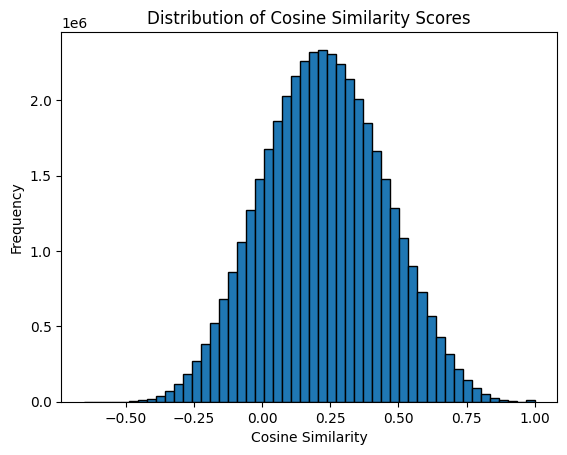

In [ ]:
S = cosine_similarity_faiss(question_embeddings)

upper_triangle = S[np.triu_indices_from(S)]

plt.hist(upper_triangle, bins=50, edgecolor='black')
plt.title('Distribution of Cosine Similarity Scores')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

In [ ]:
k = 250

In [ ]:
# 250 - 300 working fine
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(question_embeddings)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [ ]:
show_cluster_examples('question')


🔹 Cluster 0 (size=23):
  - ['message', 'sent', 'former', 'vice', 'president', 'jorge', 'glas', 'social', 'rehabilitation', 'center', 'crs', 'cotopaxi']
  - ['president', 'muhammadu', 'buhari', 'appoint', 'new', 'director', 'general', 'national', 'intelligence', 'agency']
  - ['appointed', 'new', 'president', 'minus33']
  - ['replaced', 'jack', 'fishman', 'president', 'ceo', 'san', 'antonio', 'symphony']
  - ['appointed', 'chief', 'marketing', 'officer', 'john', 'hancock', 'financial']
  - ['david', 'kahn', 'wolves', 'president', 'basketball', 'operations', 'fined']
  - ['elected', 'new', 'vice', 'president', 'india']
  - ['president', 'ceo', 'solvusoft', 'corporation']
  - ['named', 'vice', 'president', 'administration', 'human', 'resources', 'milwaukee', 'brewers', 'june', '1995']
  - ['young', 'officer', 'whisper', 'president', 'cell']
  - ['president', 'chief', 'executive', 'officer', 'sagicor', 'group', 'jamaica']
  - ['appointed', 'first', 'vice', 'president', 'strategic', 'partn

In [ ]:
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(answer_embeddings)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [ ]:
show_cluster_examples('answer')


🔹 Cluster 0 (size=53):
  - ['yes', 'big', 'snowfalls', 'slow', 'things', 'transportation', 'hill', 'goes', 'slower', 'snow', 'removal', 'takes', 'longer', 'avalanche', 'work', 'takes', 'longer', 'could', 'delays', 'take', 'hours', 'days', 'get', 'terrain', 'open', 'big', 'snow', 'storms', 'also', 'complicate', 'highway', 'travel']
  - ['three', 'categories', 'repairs', 'come', 'home', 'inspection', 'ones', 'pretty', 'much', 'required', 'according', 'inspector', 'ones', 'typically', 'required', 'ones', 'debate']
  - ['brainchild', 'behind', 'smart', 'cars', 'nicolas', 'hayek', 'man', 'behind', 'swatch', 'initial', 'vision', 'vehicles', 'make', 'small', 'city', 'car', 'would', 'fuel', 'efficient', 'easy', 'park', 'small', 'spaces', 'disappointed', 'conventional', 'engine', 'used', 'instead', 'hybrid', 'electric', 'one', 'price', 'car', 'far', 'envisaged']
  - ['user', 'upset', 'bus', 'dependability', 'rain', 'got', 'soaked', 'take', 'cab']
  - ['hatstand', 'opera', 'requires', 'minimum'

### Let's now use a Transformer to create the embeddings 

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2") 
question_embeddings = model.encode(tokenized_questions.tolist(), show_progress_bar=True)

Batches:   0%|          | 0/284 [00:00<?, ?it/s]

In [ ]:
#k, S = guess_k_for_clustering(question_embeddings, 0.99)
print(k)

250


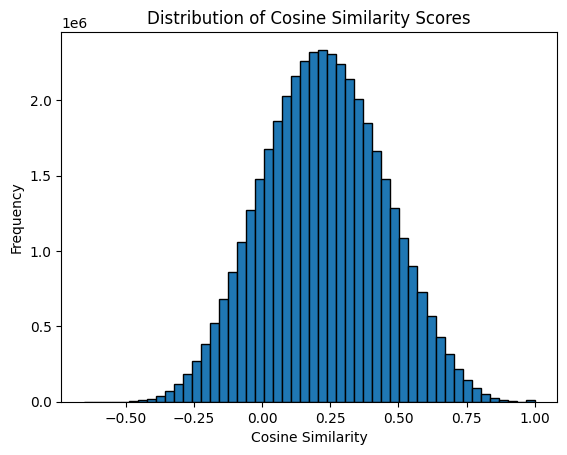

In [ ]:
upper_triangle = S[np.triu_indices_from(S)]

plt.hist(upper_triangle, bins=50, edgecolor='black')
plt.title('Distribution of Cosine Similarity Scores')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=300, random_state=0)
labels = kmeans.fit_predict(question_embeddings)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [ ]:
show_cluster_examples('question', 10)


🔹 Cluster 0 (size=33):
  - ['summer', 'school', 'math', 'english', 'science', 'credit', 'retrieval', 'take', 'place']
  - ['rules', 'groovy', 'compiled', 'bytecode']
  - ['fire', 'ice', 'heating', 'cooling', 'established']
  - ['sunset', 'slots', 'casino', 'established']
  - ['poem', 'april', '30', 'titled']
  - ['solar', 'heated', 'pool', 'work']
  - ['measures', 'winterwondergrass', 'festival', 'take', 'promote', 'sustainability']
  - ['wildfire', 'season', 'officially', 'end', 'santa', 'rosa']
  - ['real', 'salt', 'lake', 'record', 'hosting', 'mls', 'games', 'expansion', 'side', 'making', 'utah', 'debut']
  - ['sole', 'survivor', 'battle', 'jutland']
  - ['nyx', 'liquid', 'crystal', 'body', 'liner', 'infused']
  - ['recent', 'poem', 'written', 'laura', 'kennedy', 'according', 'list']
  - ['hottest', 'coldest', 'months', 'saucier', 'mississippi']
  - ['speculated', 'temperature', 'oven', 'context']
  - ['snowy', 'egrets', 'rare', 'late', '1800s']
  - ['cough', 'cold', 'remedies', 'h

In [ ]:
show_cluster_examples('answer')

ValueError: array length 9074 does not match index length 9444

In [ ]:
#show_cluster_examples('context')

In [ ]:
answer_embeddings = model.encode(tokenized_answers.tolist(), show_progress_bar=True)


In [ ]:
kmeans = KMeans(n_clusters=300, random_state=0)
labels = kmeans.fit_predict(answer_embeddings)

In [ ]:
show_cluster_examples('answer')

## Training Models

### ENCODER (Bert Family) --> Topic modelling / CLustering                              (Claudia, Edoardo)

    Topic Modelling (Cludia): use an encoder like BertTopic to find the topics in the contexts and and questions.
    
    Attention (Edoardo): C, Q, A columns in the train dataset, use the train dataset with BERT encoder to create Context + Question Sentence embeddings and use BertTopic for topic-modelling. Then use standard BertViz library or equivalent to calculate attention maps 

### TRANSFORMER           --> Q&A [Zero Shot - RAG - RAG Few Shots train - Fine Tuning] (Alberto)
    Find a suitable transformer (Encoder-Decoder) architecture to do Q&A on train dataset. Compare goodness of answers using cosine similarity on sentence embeddings. Try Zero-shot...
    Fine-tuning: if resources are available.

    Document-query similarity: use an instance of BERT to calculate document-query similarity to see how relevant is the answer to the context we have.

### LLM (GPT2, LLAMA)     --> Q&A [Zero Shot - RAG - RAG Few Shots train - Fine Tuning] (Martina)
    Find a suitable transformer (Encoder-Decoder) architecture to do Q&A on train dataset. Compare goodness of answers using cosine similarity on sentence embeddings. Try Zero-shot...
    Fine-tuning: if resources are available. 

    How to do RAG: take both Train - Test context and try to combine them all into one Dataset to chunk and use it to do RAG on questions.

### CHATBOT               --> FINAL [Text to speech, Streamlit]
